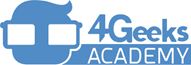

<h1><b>Data Science and Machine Learning</b></h1>
<h2><b>Clase 28</b>: Sistemas de Recomendación</h2>
<h3><b>Docente</b>: <a href="https://www.linkedin.com/in/danielablanco/">Daniela Blanco</a>

# Contenido

- [1. ¿Qué es un sistema de recomendación?](#sistema)
- [2. Tipos de sistemas de recomendación](#tipos)
- [3. Ejemplo de uso](#ejemplo)
- [4. Links de interés](#links)


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import TruncatedSVD

import warnings

In [2]:
warnings.filterwarnings("ignore")

## 1. ¿Qué es un sistema de recomendación? <a name="sistema"></a>

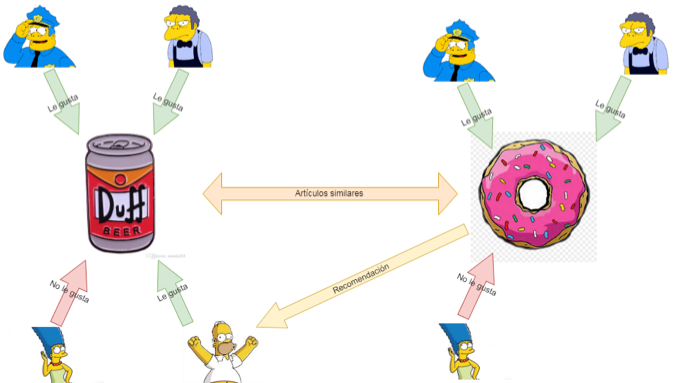

Un sistema de recomendación es un modelo computacional que estima el grado de interés que un usuario podría tener sobre un conjunto de ítems que todavía no ha consumido.

El objetivo principal es filtrar y priorizar información relevante para el usuario, mejorando su experiencia y reduciendo la sobrecarga de información.

Para lograrlo, el sistema analiza datos históricos, patrones de comportamiento, atributos de los ítems, características del usuario o incluso información contextual como el horario del día o el tipo de dispositivo.

No se limita a “mostrar cosas similares”: opera sobre un proceso continuo de aprendizaje de preferencias, que se actualiza a medida que el usuario interactúa con la plataforma.

Datos a usar:
- Explícitos: valoraciones (estrellas), likes, reviews.
- Implícitos: clics, tiempo de visualización, compras, tiempo de escucha.
- Contextuales: dispositivo, hora del día, clima, ubicación.

Algunos ejemplos de elementos que puede recomendar un sistema son:

- Películas (Netflix)
- Productos (Amazon)
- Canciones (Spotify)
- Artículos de noticias (Google News)
- Personas o perfiles (LinkedIn, Facebook)

## 2. Tipos de sistemas de recomendación <a name="tipos"></a>

Existen distintos enfoques, cada uno con ventajas y desventajas.

El diseño de un sistema adecuado dependerá del tipo de datos disponibles, el objetivo del sistema y los recursos computacionales.

### **1. Filtrado Basado en Contenido (Content-Based Filtering)**

Se basa en las **características del ítem**, no en otros usuarios.

*"Si un usuario disfrutó ciertos ítems, es razonable suponer que disfrutará otros que tengan características similares."*

**Ejemplo**: Si un usuario ha visto películas de acción con tramas rápidas y protagonistas fuertes, el sistema le recomendará otras películas con esas características, aunque nadie más las haya visto.

*Cómo funciona:*
- Cada elemento se representa como un vector de características que describe sus atributos más relevantes.
  - Herramientas: TF-IDF, onehot, embeddings.
- Se construye un perfil del usuario (vector) con base en los elementos que consumio.
- Se calculan similitudes entre el perfil del usuario y todos los ítems disponibles.
  - Métricas: similitud de coseno, jaccard, distancia Euclidiana, Overlap.
- Se recomiendan los elementos más parecidos.

#### Ventajas:

- Personalización individual.
- No necesita datos de otros usuarios.
- Funciona inclusive si el ítem es nuevo o poco popular.

#### Desventajas:

- Se "encierra" en los mismos gustos (sobre-especialización).
    
    Si alguien siempre consume ciencia ficción, el sistema probablemente seguirá recomendando solo ciencia ficción, impidiendo la exploración de nuevas categorías
- No descubre intereses nuevos.

###**2. Filtrado Colaborativo (CF) (Collaborative Filtering)**

Se basa en la interacción de múltiples **usuarios**.

*“Si a un grupo de usuarios similares les gusta un ítem, es probable que también te guste a ti”*.

**Ejemplo**: Si dos usuarios tienen gustos similares y uno de ellos valora positivamente una película nueva, esa película será recomendada al otro usuario.

*Cómo funciona:*

Este método construye una gran matriz que representa las interacciones: cada fila corresponde a un usuario y cada columna a un ítem, y cada celda incluye una valoración, un clic, un “me gusta” o cualquier indicador de consumo.

Este tipo de matriz suele ser extremadamente dispersa —la mayoría de los usuarios consumen solo una fracción mínima del catálogo—, lo cual presenta desafíos computacionales.

#### Dos enfoques principales:

- Basado en usuarios: Encuentra usuarios similares (vecinos) al usuario objetivo y recomienda los ítems que a ellos les gustaron.

  Usuario A y B tienen gustos muy parecidos.

  A le gustó una película que B no vio.

  Se la recomendamos a B.

- Basado en ítems: compara ítems entre sí buscando aquellos que suelen ser consumidos por patrones demográficos o conductuales similares.

  Si quienes vieron “Película A” también vieron “Película B”, entonces se recomienda "B" a quienes disfrutaron "A".

#### Algoritmos comunes:

- K-Nearest Neighbors (KNN).
- Correlación de Pearson.
- Factorización de matrices (Matrix Factorization), como SVD o NMF.

#### Ventajas:

- Descubre contenido inesperado
- Aprovecha tendencias colectivas

#### Desventajas:

- Problema del arranque en frío: usuarios o ítems nuevos sin datos suficientes.
- Matriz de datos dispersa: pocos ítems calificados por usuario.
- Escalabilidad.

###**3. Sistemas Híbridos**

La mayoría de los sistemas de recomendación reales no utiliza únicamente filtrado basado en contenido o colaborativo, sino una integración de ambos.

La razón es evidente: cada enfoque resuelve problemas distintos y presenta debilidades complementarias.

Los híbridos pueden combinar modelos de manera secuencial, paralela o jerárquica.

  Por ejemplo, un modelo basado en contenido puede generar una primera lista de candidatos, y luego un modelo colaborativo los reordena según afinidades entre usuarios.
  
  También puede suceder lo contrario: el sistema colaborativo predice ítems prometedores, pero luego un modelo basado en contenido verifica que esos ítems realmente coincidieran con los intereses del usuario.

**Ejemplo**: Un servicio de música puede recomendar canciones basándose en el historial del usuario y en las preferencias de otros usuarios similares.

#### Ventajas:

- Mayor precisión.
- Soluciona problemas de arranque en frío.
- Más robusto frente a cambios en los datos

#### Desventajas:

- Mayor complejidad en la implementación.
- Necesita coordinación entre modelos.

## 3. Ejemplo de uso <a name="ejemplo"></a>

The Movies Dataset, disponible en [Kaggle](https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset?resource=download&select=ratings_small.csv).

Se trata de un conjunto de datos creado originalmente para un desafío de recomendación, y que contiene información basada en películas, metadatos descriptivos y calificaciones de usuarios.

In [3]:
# conexion drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
archivo  = '/content/drive/MyDrive/4Geeks/DS/2.0/28_sistemas_de_recomendacion/data/movies_metadata.csv'

movies  = pd.read_csv(archivo)

In [5]:
movies.shape

(45466, 24)

In [6]:
archivo  = '/content/drive/MyDrive/4Geeks/DS/2.0/28_sistemas_de_recomendacion/data/ratings_small.csv'

ratings = pd.read_csv(archivo)

In [7]:
ratings.shape

(100004, 4)

#### Procesamiento de datos

Por simplicidad nos quedamos solo con id, title, overview y genres.

In [8]:
movies.dropna(subset=['overview'], inplace=True)

movies.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


En este dataset, la columna id debería contener solo números, pero en realidad tiene algunas filas con valores incorrectos que incluyen fechas u otros textos.

In [9]:
movies['id'] = movies['id'].astype(int)

ValueError: invalid literal for int() with base 10: '1997-08-20'

La solución es limpiar y convertir la columna id de manera segura, ignorando las filas incorrectas.

In [10]:
# Convertir la columna id a numérico (los errores se ponen como NaN)
movies['id'] = pd.to_numeric(movies['id'], errors='coerce')

# Eliminar filas cuyo id no sea numérico
movies = movies.dropna(subset=['id'])

# Convertir definitivamente a entero
movies['id'] = movies['id'].astype(int)

Renombramos ratings.movieId a ratings.id solo si coincide con movies.id para que los datos se unan correctamente.

In [11]:
# ratings que no tienen esa id se descartan
ratings_fix = ratings.rename(columns={'movieId': 'id'})
ratings_fix = ratings_fix[ratings_fix['id'].isin(movies['id'])]

In [16]:
ratings_fix.head()

,userId,id,rating,timestamp
10,1,1371,2.5,1260759135
11,1,1405,1.0,1260759203
13,1,2105,4.0,1260759139
15,1,2193,2.0,1260759198
16,1,2294,2.0,1260759108


#### Filtrado Basado en Contenido

Para construir un recomendador basado en contenido vamos a trabajar únicamente con la sinopsis de cada película.

Usaremos TF-IDF para vectorizar y Cosine Similarity como métrica.

Transformamos esas sinopsis en vectores numéricos usando TF-IDF, y a partir de esos vectores podemos medir qué tan parecidas son dos películas utilizando la similitud del coseno.

In [12]:
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movies['overview'])

tfidf_matrix.shape

(44509, 75827)

Esa matriz es cuadrada: cada fila y cada columna representan una película; la entrada (i, j) indica “qué tan similar es la película i a la película j en términos de contenido textual.

Calcular la matriz completa de similitudes entre todas las películas puede ocupar demasiada memoria.

Para evitarlo, en lugar de generar una matriz gigante de todas contra todas, vamos a calcular la similitud solo entre la película elegida y todas las demás, en el momento en que se hace la consulta.

In [13]:
indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

def recomendar_por_contenido(titulo, n=10):
    idx = indices[titulo]
    # solo comparamos la película elegida contra todas
    sim_scores = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()

    # ordenar
    sim_indices = sim_scores.argsort()[::-1][1:n+1]

    return movies['title'].iloc[sim_indices]

- Buscamos el índice de la película dentro del DataFrame para poder acceder a su vector TF-IDF.

- Calculamos la similitud del coseno entre ese vector y todos los vectores del catálogo.

- Ordenamos esos valores de similitud de mayor a menor.

- Tomamos las n películas más similares (excluyendo la misma película).

- Devolvemos sus títulos.

In [14]:
recomendar_por_contenido("Toy Story")

,title
15348,Toy Story 3
2997,Toy Story 2
10301,The 40 Year Old Virgin
24523,Small Fry
23843,Andy Hardy's Blonde Trouble
29202,Hot Splash
43427,Andy Kaufman Plays Carnegie Hall
38476,Superstar: The Life and Times of Andy Warhol
42721,Andy Peters: Exclamation Mark Question Point
8327,The Champ


In [15]:
recomendar_por_contenido("Star Wars")

,title
6902,Little Women
4791,Little Women
39092,The Night Holds Terror
9452,Lucky 7
29288,Copperhead
958,Fly Away Home
43573,Bad Girl
40591,Three Days
7317,Desperate Hours
43774,Ramona


#### Filtrado Colaborativo basado en item

Utilizamos KNN como algoritmo.

In [17]:
user_item_matrix  = ratings_fix.pivot_table(index='userId', columns='id', values='rating')
user_item_matrix  = user_item_matrix.fillna(0)

In [18]:
user_item_matrix.head()

id,2,3,5,6,11,12,13,14,15,16,...,132961,133365,134158,134569,134881,140174,142507,148652,158238,160718
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Esta línea transforma nuestra tabla original de ratings en una matriz usuario-película.

Hasta ahora cada fila tiene userId, movieId y rating.

Con pivot_table() convertimos eso en una tabla donde:

- cada fila representa un usuario,
- cada columna representa una película,
- cada celda contiene la puntuación que ese usuario dio a esa película.

Si el usuario no calificó esa película, la celda queda en NaN.

In [19]:
user_item_matrix  = user_item_matrix.T

El algoritmo k-NN funciona buscando vecinos cercanos entre filas, no entre columnas. Queremos encontrar películas similares entre sí, no usuarios similares.

Lo resolvemos haciendo la transpuesta de la matriz.

In [20]:
knn = NearestNeighbors(metric='cosine', algorithm='brute')

knn.fit(user_item_matrix )

NearestNeighbors(algorithm='brute', metric='cosine')

Función para recomendar:

In [21]:
def recomendar_knn(titulo, n=10):
    # Buscamos el ID
    movie_id = int(movies.loc[movies['title'] == titulo, 'id'].iloc[0])

    # Si ese ID no está en la matriz, no se puede hacer kNN
    if movie_id not in user_item_matrix.index:
        return ["Esta película no tiene suficientes ratings"]

    # Vector
    movie_vector = user_item_matrix.loc[movie_id].values.reshape(1, -1)

    # kNN
    distances, indices_knn = knn.kneighbors(movie_vector, n_neighbors=n+1)

    # IDs recomendados
    similar_ids = user_item_matrix.iloc[indices_knn[0][1:]].index

    # Convertimos a títulos
    return movies[movies['id'].isin(similar_ids)]['title'].tolist()

In [22]:
recomendar_knn("Toy Story")

['Esta película no tiene suficientes ratings']

In [23]:
recomendar_knn("Star Wars")

["Muriel's Wedding",
 'Willy Wonka & the Chocolate Factory',
 'Psycho',
 'Night on Earth',
 'A Nightmare on Elm Street',
 'Titanic',
 'Rain Man',
 'Big Fish',
 'Young Adam',
 'Aliens vs Predator: Requiem']

#### Sistema Híbrido

La idea del sistema híbrido es mezclar lo mejor de los dos mundos:

- del basado en contenido tomamos películas similares en temática;
- del colaborativo tomamos películas que suelen ver los mismos usuarios.

Al combinar de forma ponderada ambas recomendaciones, obtenemos resultados más precisos.

In [24]:
def recomendacion_hibrida(titulo, peso_cbf=0.5, peso_knn=0.5):
    id_movie = int(movies[movies['title'] == titulo]['id'].values[0])

    contenido = recomendar_por_contenido(titulo, n=20)
    cbf_scores = {t:20-i for i,t in enumerate(contenido)}

    try:
        knn_rec = recomendar_knn(id_movie, n=20)
        knn_scores = {t:20-i for i,t in enumerate(knn_rec)}
    except:
        knn_scores = {}

    # combinación
    final_scores = {}
    for t in set(list(cbf_scores.keys()) + list(knn_scores.keys())):
        final_scores[t] = peso_cbf*cbf_scores.get(t,0) + peso_knn*knn_scores.get(t,0)

    final = sorted(final_scores.items(), key=lambda x: x[1], reverse=True)[:10]
    return [x[0] for x in final]

In [25]:
recomendacion_hibrida("Toy Story")

['Toy Story 3',
 'Toy Story 2',
 'The 40 Year Old Virgin',
 'Small Fry',
 "Andy Hardy's Blonde Trouble",
 'Hot Splash',
 'Andy Kaufman Plays Carnegie Hall',
 'Superstar: The Life and Times of Andy Warhol',
 'Andy Peters: Exclamation Mark Question Point',
 'The Champ']

In [26]:
recomendacion_hibrida("Star Wars")

['Little Women',
 'The Night Holds Terror',
 'Lucky 7',
 'Copperhead',
 'Fly Away Home',
 'Bad Girl',
 'Three Days',
 'Desperate Hours',
 'Ramona',
 'This Happy Breed']

## 4. Links de interés <a name="links"></a>

- [Sistemas de Recomendación](https://www.aprendemachinelearning.com/sistemas-de-recomendacion/?utm_source=chatgpt.com)
- [Classification of text documents using sparse features](https://scikit-learn.org/stable/auto_examples/text/plot_document_classification_20newsgroups.html)
- [Matrix Factorization Techniques for Recommender Systems](https://datajobs.com/data-science-repo/Recommender-Systems-%5BNetflix%5D.pdf)